Faire colonne délai entre date de cancer et date de questionnaire

# Import Environment variables

In [7]:
%run /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables.ipynb

Found bucket: id=rw-migration-aou-rw-f7a4d148, bucketName=rw-migration-aou-rw-f7a4d148
-> Assigned migration variables (ID: rw-migration-aou-rw-f7a4d148)
Found bucket: id=temporary-workspace-bucket, bucketName=temporary-workspace-bucket-wb-perky-cabbage-8342
Found bucket: id=workspace-bucket, bucketName=workspace-bucket-wb-perky-cabbage-8342
✅ Successfully identified latest dataset: wb-silky-artichoke-2408.C2024Q3R9

Variables extracted:
GOOGLE_CLOUD_PROJECT: wb-perky-cabbage-8342
WORKSPACE_BUCKET: gs://workspace-bucket-wb-perky-cabbage-8342
WORKSPACE_TEMP_BUCKET: gs://temporary-workspace-bucket-wb-perky-cabbage-8342
WORKSPACE_CDR: wb-silky-artichoke-2408.C2024Q3R9
bucket_aou_tutorial: NOT FOUND
bucket_id_aou_tutorial: NOT FOUND
bucket_migrated: gs://rw-migration-aou-rw-f7a4d148
bucket_id_migrated: rw-migration-aou-rw-f7a4d148

✅ Saved to /home/jupyter/.bashrc
C2024Q3R9 BQ_DATASET
Multi-trait-GWAS-in-admixed-populations GIT_REPO
dataset_test2 BQ_DATASET
prep_C2024Q3R9 BQ_DATASET
rw-mig

In [8]:
%run /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables_p2.ipynb

WORKSPACE_CDR = wb-silky-artichoke-2408.C2024Q3R9
WORKSPACE_BUCKET = gs://workspace-bucket-wb-perky-cabbage-8342
GOOGLE_PROJECT = wb-perky-cabbage-8342
Done! 10 variables saved to: /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables_p2.R
Done! 10 variables saved to: /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables.sas


# Import library

In [9]:
%load_ext autoreload
%autoreload 2
    
import os
import subprocess
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data's import

## Data from `50_Breast_Cancer_WITHIN_5Y`

* Femmes n'ayant pas eu de cancer avant l'inclusion (BC and not BC included without time constraints) for all time)
* Origine génétique (RYE)
* Biopsie

In [13]:
# get the bucket name
my_bucket = os.getenv('WORKSPACE_TEMP_BUCKET')
name_of_file_in_bucket = "df_bc_ko_at_inclusion_223k_nb_BC_WITHIN_5Y_GeneticAncestry_biopsy.tsv"

# save dataframe in a csv file in the same workspace as the notebook
df_bc = pd.read_csv(my_bucket +'/'+ name_of_file_in_bucket, sep=',', low_memory=False)
df_bc

,person_id,gender,date_of_birth,ethnicity,self_reported_category,inclusion_date,first_breast_cancer_date,delay_days,delay_years,time_category,...,date_3_of_biopsy_19100_19103,has_biopsy_19100_19103,date_1_of_biopsy_19120_19125_19126,date_2_of_biopsy_19120_19125_19126,date_3_of_biopsy_19120_19125_19126,has_biopsy_19120_19125_19126,biopsy_result,first_any_biopsy_date,days_inclusion_to_biopsy,days_biopsy_to_cancer
0,7604109,Female,1953-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2022-03-29,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN
1,2382559,Female,1988-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2022-04-04,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN
2,2032331,Female,1954-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2019-09-17,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN
3,3382692,Female,1957-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2018-07-17,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN
4,2537673,Female,1965-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2019-03-04,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223201,8122695,Female,2002-06-15,Not Hispanic or Latino,White,2023-06-21,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN
223202,3902303,Female,2003-06-15,Not Hispanic or Latino,White,2022-12-12,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN
223203,9743793,Female,2003-06-15,Not Hispanic or Latino,White,2022-12-27,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN
223204,4702863,Female,2003-06-15,Not Hispanic or Latino,White,2023-02-24,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN


# Family History data processing

## Importing family_history data (statement)

In [14]:
import pandas
import os

# This query represents dataset "Personal and family health history (with datetime)" for domain "survey" and was generated for All of Us Controlled Tier Dataset v8
dataset_80480060_survey_sql = """
    SELECT
        answer.person_id,
        answer.survey_datetime,
        answer.survey,
        answer.question,
        answer.answer,
        answer.survey_version_name  
    FROM
        `""" + os.environ["WORKSPACE_CDR"] + """.ds_survey` answer   
    WHERE
        (
            question_concept_id IN (836772)
        )"""

dataset_80480060_survey_df = pandas.read_gbq(
    dataset_80480060_survey_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook")

dataset_80480060_survey_df.head(5)

/tmp/ipykernel_8021/2260101942.py:20: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  dataset_80480060_survey_df = pandas.read_gbq(


Downloading:   0%|          |

,person_id,survey_datetime,survey,question,answer,survey_version_name
0,3506594,2023-03-01 01:09:16+00:00,Personal and Family Health History,"Including yourself, who in your family has had...","Including yourself, who in your family has had...",None
1,1083314,2023-04-21 16:22:14+00:00,Personal and Family Health History,"Including yourself, who in your family has had...","Including yourself, who in your family has had...",None
2,1657008,2018-10-12 22:34:14+00:00,Personal and Family Health History,"Including yourself, who in your family has had...","Including yourself, who in your family has had...",None
3,1382181,2020-04-26 16:20:36+00:00,Personal and Family Health History,"Including yourself, who in your family has had...","Including yourself, who in your family has had...",None
4,1565942,2019-12-29 23:59:13+00:00,Personal and Family Health History,"Including yourself, who in your family has had...","Including yourself, who in your family has had...",None


In [15]:
dataset_80480060_survey_df['answer'].value_counts()

answer
PMI: Skip                                                                      84502
Including yourself, who in your family has had breast cancer? - Grandparent    31388
Including yourself, who in your family has had breast cancer? - Mother         27214
Including yourself, who in your family has had breast cancer? - Sibling        13804
Including yourself, who in your family has had breast cancer? - Self           10627
Including yourself, who in your family has had breast cancer? - Daughter        1250
Including yourself, who in your family has had breast cancer? - Father           824
Including yourself, who in your family has had breast cancer? - Son               57
Name: count, dtype: int64

# Features engineering

## Création d'une colonne par membres de la famille

In [16]:
list_answer = list(dataset_80480060_survey_df['answer'].unique())
list_answer

['Including yourself, who in your family has had breast cancer? - Daughter',
 'Including yourself, who in your family has had breast cancer? - Father',
 'Including yourself, who in your family has had breast cancer? - Grandparent',
 'Including yourself, who in your family has had breast cancer? - Mother',
 'Including yourself, who in your family has had breast cancer? - Self',
 'Including yourself, who in your family has had breast cancer? - Sibling',
 'PMI: Skip',
 'Including yourself, who in your family has had breast cancer? - Son']

In [17]:
# 1. Nettoyer les noms des colonnes pour ne garder que le membre de la famille
# On retire le préfixe répétitif pour avoir des colonnes lisibles
dataset_80480060_survey_df['clean_answer'] = dataset_80480060_survey_df['answer'].str.split(' - ').str[-1]

In [18]:
family_list = ['Daughter','Mother','Sibling']

df_survey_family = dataset_80480060_survey_df[dataset_80480060_survey_df['clean_answer'].isin(family_list)]

In [19]:
df_survey_clean = df_survey_family.copy()

# 2. Création d'une colonne de présence (1) pour le pivot
df_survey_clean['presence'] = 1

# 3. Pivotage : on transforme les valeurs de 'answer' en colonnes
# On utilise 'max' pour que si la personne a répondu 2 fois la même chose, on garde juste 1
df_pivot = df_survey_clean.pivot_table(
    index='person_id', 
    columns='clean_answer', 
    values='presence', 
    aggfunc='max'
).fillna(0).astype(int)

## Traitement des dates

### Ajout d'une colonne `first` et `last`

In [20]:
dataset_80480060_survey_df['survey_day'] = pd.to_datetime(dataset_80480060_survey_df['survey_datetime'], errors="coerce").dt.tz_localize(None).dt.normalize()

In [21]:
# 4. Récupération des dates (Première et Dernière réponse)
# C'est important pour savoir à quel moment l'info a été collectée
df_dates = dataset_80480060_survey_df.groupby('person_id')['survey_day'].agg(
    first_survey_date='min',
    last_survey_date='max'
)

### Ajout d'une variable `days_last_survey_to_first_survey` pour identifier le délai entre la 1ère et la dernière réponses au questionnaire

In [22]:
df_dates['days_last_survey_to_first_survey'] = (df_dates['last_survey_date'] - df_dates['first_survey_date']).dt.days

## Rassemblement des données contenant les antécédent familiaux 

In [23]:
df_family_history = df_dates.merge(df_pivot, on='person_id', how='right')

# Fusion avec le main set

In [24]:
df = df_bc.merge(df_family_history, on='person_id', how='left', indicator=True)
df

,person_id,gender,date_of_birth,ethnicity,self_reported_category,inclusion_date,first_breast_cancer_date,delay_days,delay_years,time_category,...,first_any_biopsy_date,days_inclusion_to_biopsy,days_biopsy_to_cancer,first_survey_date,last_survey_date,days_last_survey_to_first_survey,Daughter,Mother,Sibling,_merge
0,7604109,Female,1953-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2022-03-29,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,left_only
1,2382559,Female,1988-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2022-04-04,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,left_only
2,2032331,Female,1954-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2019-09-17,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,left_only
3,3382692,Female,1957-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2018-07-17,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,left_only
4,2537673,Female,1965-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2019-03-04,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223201,8122695,Female,2002-06-15,Not Hispanic or Latino,White,2023-06-21,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,left_only
223202,3902303,Female,2003-06-15,Not Hispanic or Latino,White,2022-12-12,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,left_only
223203,9743793,Female,2003-06-15,Not Hispanic or Latino,White,2022-12-27,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,left_only
223204,4702863,Female,2003-06-15,Not Hispanic or Latino,White,2023-02-24,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,left_only


In [25]:
df['_merge'].value_counts()

_merge
left_only     207305
both           15901
right_only         0
Name: count, dtype: int64

In [26]:
df = df.drop(columns='_merge')

# Feature engineering - Etape 2

## Ajout d'une variable `days_inclusion_to_first_survey` pour identifier le délai entre les réponses au questionnaire et la date d'inclusion

In [27]:
df['inclusion_date'] = pd.to_datetime(df['inclusion_date'], errors="coerce").dt.tz_localize(None).dt.normalize()

In [28]:
df['days_inclusion_to_first_survey'] = (df['first_survey_date'] - df['inclusion_date']).dt.days

## Ajout d'une variable `days_inclusion_to_last_survey` pour identifier le délai entre les réponses au questionnaire et la date d'inclusion

In [29]:
df['days_inclusion_to_last_survey'] = (df['last_survey_date'] - df['inclusion_date']).dt.days

In [30]:
df[family_list+['days_inclusion_to_first_survey','days_last_survey_to_first_survey']].dropna()

,Daughter,Mother,Sibling,days_inclusion_to_first_survey,days_last_survey_to_first_survey
38,0.0,1.0,0.0,344.0,0.0
50,0.0,1.0,0.0,20.0,0.0
52,0.0,1.0,0.0,470.0,0.0
53,0.0,1.0,0.0,1576.0,0.0
169,0.0,0.0,1.0,1373.0,0.0
...,...,...,...,...,...
223043,0.0,1.0,0.0,0.0,0.0
223072,0.0,1.0,0.0,6.0,0.0
223089,0.0,1.0,0.0,0.0,0.0
223117,0.0,1.0,0.0,0.0,0.0


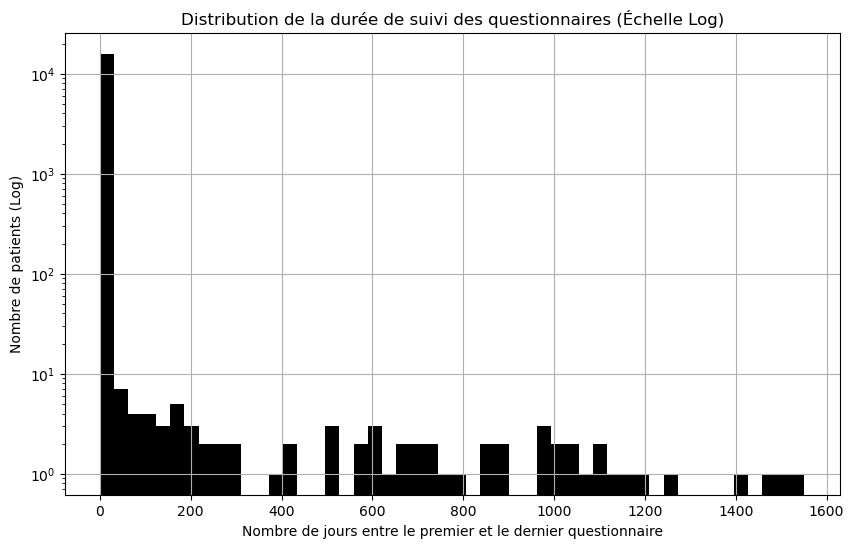

In [31]:
# On filtre les données pour enlever les NaN
data_to_plot = df['days_last_survey_to_first_survey'].dropna()

# Création de l'histogramme avec échelle log sur l'axe Y
plt.figure(figsize=(10, 6))
data_to_plot.hist(bins=50, log=True, color='black')

plt.title('Distribution de la durée de suivi des questionnaires (Échelle Log)')
plt.xlabel('Nombre de jours entre le premier et le dernier questionnaire')
plt.ylabel('Nombre de patients (Log)')
plt.show()

# Combinations analysis 

In [37]:
from upsetplot import UpSet, from_indicators
import matplotlib.pyplot as plt

cols = df.drop(columns=['person_id','first_survey_date','last_survey_date']).columns.tolist()

data = from_indicators(cols, df[cols].astype(bool))

N = len(df)

fig = plt.figure(figsize=(14,10))

up = UpSet(
    data,
    subset_size="count",
    show_counts=True,
    show_percentages=True,
    sort_by="cardinality",
    element_size=45
)

up.plot(fig=fig)

plt.suptitle(
    f"Intersection des antécédents familiaux\n"
    f"Distribution selon le type de parenté (N = {N})",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig("family_history_v1.png", dpi=300, bbox_inches='tight')

plt.show()

/opt/conda/envs/jupyter/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/opt/conda/envs/jupyter/lib/python3.12/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behave

TypeError: only 0-dimensional arrays can be converted to Python scalars

Error in callback <function _draw_all_if_interactive at 0x7ff386516160> (for post_execute), with arguments args (),kwargs {}:


TypeError: only 0-dimensional arrays can be converted to Python scalars

TypeError: only 0-dimensional arrays can be converted to Python scalars

<Figure size 67562.5x2937.5 with 4 Axes>

In [41]:
from upsetplot import UpSet, from_indicators
import matplotlib.pyplot as plt

verif = verif[verif['has_bc'] == 1]

cols = [
    "Daughter",
    "Mother",
    "PMI: Skip",
    "Self",
    "Sibling",
]

data = from_indicators(cols, verif[cols].astype(bool))

N = len(verif)

fig = plt.figure(figsize=(14,10))

up = UpSet(
    data,
    subset_size="count",
    show_counts=True,
    show_percentages=True,
    sort_by="cardinality",
    element_size=45
)

up.plot(fig=fig)

plt.suptitle(
    f"Intersection des antécédents familiaux de cancer du sein\n"
    f"Distribution selon le type de parenté (N = {N})",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig("family_history_v1.png", dpi=300, bbox_inches='tight')

plt.show()

NameError: name 'verif' is not defined

In [38]:
summary = (
    verif
    .groupby(cols)["has_bc"]
    .agg(
        n_individuals="count",
        n_bc="sum",
        prevalence_bc="mean"
    )
    .reset_index()
)

summary["prevalence_bc"] = summary["prevalence_bc"] * 100

summary

NameError: name 'verif' is not defined

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=summary,
    x="prevalence_bc",
    y=summary[cols].astype(str).agg(" + ".join, axis=1),
    color="#B43E3B"
)

plt.xlabel("Prévalence du cancer du sein (%)")
plt.ylabel("Combinaison des antécédents familiaux")
plt.title("Prévalence du cancer selon les intersection des antécédents familiaux", weight="bold")

plt.show()

NameError: name 'summary' is not defined

<Figure size 800x500 with 0 Axes>

In [40]:
# On part du df_final créé précédemment (une ligne par individu, colonnes 0/1)
cols_famille = [c for c in df_final.columns if c not in ['person_id', 'Self', 
                                                         'amr_rye', 'sas_rye', 'afr_rye', 'eas_rye',
                                                         'has_bc', 'biopsy_result',
                                                         'biopsy_result_19081_19086', 
                                                         'biopsy_result_19100_19103', 
                                                         'biopsy_result_19120_19125_19126']]

# 1. Créer une colonne qui résume le "Profil" de l'individu
def get_profile(row):
    active_cols = [col for col in cols_famille if row[col] == 1]
    return " + ".join(active_cols) if active_cols else "None"

df_final['Family_Profile'] = df_final.apply(get_profile, axis=1)

# 2. Compter l'occurrence de chaque combinaison avec la présence du 'Self'
analysis = df_final.groupby(['Family_Profile', 'Self']).size().reset_index(name='Count')
analysis = analysis.sort_values(by='Count', ascending=False)

print(analysis.head(20))

NameError: name 'df_final' is not defined

In [ ]:
df_final.columns

In [ ]:
(12536+7506+3704)/70218

In [ ]:
(58+40+33+24+21+21)/677*100

In [ ]:
175/677

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def process_family_history(df):
    # 1. Nettoyage du nom du membre (on garde ce qu'il y a après le ' - ')
    df['relative'] = df['answer'].str.split(' - ').str[-1]
    
    # 2. Création des colonnes 0/1 (One-Hot Encoding)
    dummies = pd.get_dummies(df['relative'])
    
    # 3. Regroupement par individu (en supposant que vous avez une colonne 'person_id')
    # On utilise .max() pour consolider les réponses sur une seule ligne
    df_wide = pd.concat([df['person_id'], dummies], axis=1)
    df_wide = df_wide.groupby('person_id').max().reset_index()
    
    # 4. Suppression des colonnes non informatives pour l'analyse génétique
    if 'PMI: Skip' in df_wide.columns:
        df_wide = df_wide.drop(columns=['PMI: Skip'])
        
    return df_wide

# Utilisation :
df_final = process_family_history(df_family_history)

In [ ]:
# Liste des membres de la famille (on exclut 'person_id' et 'Self')
family_cols = [c for c in df_final.columns if c not in ['person_id', 'Self']]

def get_profile(row):
    # On récupère les colonnes où la valeur est 1
    active = [col for col in family_cols if row[col] == 1]
    if not active:
        return "Aucun"
    return " + ".join(sorted(active))

# On génère le profil pour chaque individu
df_final['Family_Profile'] = df_final.apply(get_profile, axis=1)

# On compte l'occurrence de chaque profil
profile_counts = df_final['Family_Profile'].value_counts().reset_index()
profile_counts.columns = ['Combinaison', 'Nombre_Individus']

print(profile_counts)

In [ ]:
# Analyse croisée entre le profil familial et la réponse "Self"
cross_tab = pd.crosstab(df_final['Family_Profile'], df_final['Self'])

# Visualisation
cross_tab.plot(kind='barh', stacked=True, figsize=(10, 7), color=['#3498db', '#e74c3c'])
plt.title('Combinaisons familiales vs Diagnostic personnel (Self)')
plt.xlabel("Nombre d'individus")
plt.ylabel("Profil des antécédents familiaux")
plt.legend(title='A eu un cancer (Self)', labels=['Non (0)', 'Oui (1)'])
plt.show()

## past tests

In [ ]:
test = dataset_85479400_survey_df['person_id'].value_counts().reset_index().sample(10)
test

1. mother = 1 / Self = 0
2. mother = 1 / Self = NaN
3. mother = 2 / Self = 0
4. mother = 2 / Self = NaN

Filtre, tout les self 1 qui sont 1 partout, mettre 0

Mettre tout les cas de figure pour pouvoir les traiter de façon individuel

In [ ]:
dataset_85479400_survey_df[dataset_85479400_survey_df['person_id'] == 1854117][['answer']].value_counts()

In [ ]:
dataset_85479400_survey_df['answer'].unique()


In [ ]:
dataset_85479400_survey_df[dataset_85479400_survey_df['answer'].str.contains('Grandparent')][['person_id']]


In [ ]:
(677-241-175-33-42)/1586

In [ ]:
(58+40+24+175)/1586

In [ ]:
(58+24+175+3+12+11)/1586

In [ ]:
(70218-39490-1988-338-270-255-1988)/221500

none = 0 -> 0
none = 1 -> 0 

In [ ]:
(3704/221500)*100

In [ ]:
(24/1586)*100

In [ ]:
169282+5899+19160+1080+820+76

In [ ]:
(5899+1080+76)/196317*100

In [ ]:
(19160+820)/(196317-5899+1080+76)*100

In [ ]:
(1080+76)/(5899+1080+76)*100

# Family_history_v2

In [ ]:
import pandas
import os

# This query represents dataset "family_history_v2" for domain "survey" and was generated for All of Us Controlled Tier Dataset v8
dataset_76127477_survey_sql = """
    SELECT
        answer.person_id,
        answer.question,
        answer.answer  
    FROM
        `""" + os.environ["WORKSPACE_CDR"] + """.ds_survey` answer   
    WHERE
        (
            question_concept_id IN (43528515)
        )"""

dataset_76127477_survey_df = pandas.read_gbq(
    dataset_76127477_survey_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook")

dataset_76127477_survey_df.head(5)

In [ ]:
dataset_76127477_survey_df[dataset_76127477_survey_df['answer'].str.contains('Breast cancer')].value_counts('answer')

In [ ]:
family = dataset_76127477_survey_df[dataset_76127477_survey_df['answer'].str.contains('Breast cancer')]

In [ ]:
family_test = family.merge(df_bc, on='person_id', how='right', indicator=True)

In [ ]:
family_test['_merge'].value_counts()

In [ ]:
family_test[(family_test['_merge'] == 'right_only') & (family_test['has_bc'] == 1)]

In [ ]:
family_history_v2 = family_test[(family_test['_merge'] == 'both') & (family_test['has_bc'] == 1)].drop(columns='_merge')
family_history_v2

In [ ]:
df_family_history = dataset_85479400_survey_df.copy()

import pandas as pd

# 1. Nettoyer les noms des colonnes pour ne garder que le membre de la famille
# On retire le préfixe répétitif pour avoir des colonnes lisibles
df_family_history['clean_answer'] = df_family_history['answer'].str.split(' - ').str[-1]

# 2. Créer les colonnes de présence (0 ou 1)
dummies = pd.get_dummies(df_family_history['clean_answer'])

# 3. Concaténer avec l'ID de l'individu et regrouper
# On utilise .max() pour que si une personne a plusieurs lignes, le '1' remonte
df_final = pd.concat([df_family_history['person_id'], dummies], axis=1)
df_final = df_final.groupby('person_id').max().reset_index()
df_final = df_final.astype(int)

# 4. (Optionnel) Supprimer la colonne 'PMI: Skip' si elle ne t'est pas utile
#if 'PMI: Skip' in df_final.columns:
#    df_final = df_final.drop(columns=['PMI: Skip'])

In [ ]:
verif = df_final.merge(df_bc, on='person_id', how='right', indicator=True)

In [ ]:
from upsetplot import UpSet, from_indicators
import matplotlib.pyplot as plt

cols = [
    "Daughter",
    "Mother",
    "PMI: Skip",
    "Self",
    "Sibling",
]

data = from_indicators(cols, verif[cols].astype(bool))

N = len(verif)

fig = plt.figure(figsize=(14,10))

up = UpSet(
    data,
    subset_size="count",
    show_counts=True,
    show_percentages=True,
    sort_by="cardinality",
    element_size=45
)

up.plot(fig=fig)

plt.suptitle(
    f"Intersection des antécédents familiaux\n"
    f"Distribution selon le type de parenté (N = {N})",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig("family_history_v1.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
last_test = df_final.merge(family_history_v2, on='person_id', how='right', indicator=True)

In [ ]:
last_test

In [ ]:
from upsetplot import UpSet, from_indicators
import matplotlib.pyplot as plt

cols = [
    "Daughter",
    "Mother",
    "PMI: Skip",
    "Self",
    "Sibling",
]

data = from_indicators(cols, last_test[cols].astype(bool))

N = len(last_test)

fig = plt.figure(figsize=(14,10))

up = UpSet(
    data,
    subset_size="count",
    show_counts=True,
    show_percentages=True,
    sort_by="cardinality",
    element_size=45
)

up.plot(fig=fig)

plt.suptitle(
    f"Intersection des antécédents familiaux\n"
    f"Distribution selon le type de parenté (N = {N})",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig("family_history_v1.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# On part du df_final créé précédemment (une ligne par individu, colonnes 0/1)
cols_famille = [c for c in last_test.columns if c not in ['person_id', 'Self', 
                                                         'amr_rye', 'sas_rye', 'afr_rye', 'eas_rye',
                                                         'has_bc', 'delay_days',
                                                         'biopsy_result_19081_19086', 
                                                         'biopsy_result_19100_19103', 
                                                         'biopsy_result_19120_19125_19126']]

# 1. Créer une colonne qui résume le "Profil" de l'individu
def get_profile(row):
    active_cols = [col for col in cols_famille if row[col] == 1]
    return " + ".join(active_cols) if active_cols else "None"

last_test['Family_Profile'] = last_test.apply(get_profile, axis=1)

# 2. Compter l'occurrence de chaque combinaison avec la présence du 'Self'
analysis = last_test.groupby(['Family_Profile', 'Self']).size().reset_index(name='Count')
analysis = analysis.sort_values(by='Count', ascending=False)

print(analysis.head(20))

In [ ]:
analysis['Count'].sum()